# PoltergeistNet $\Omega_{\rm GW}$ spectra via SIGWAY

Drives the **C++ PoltergeistNet** pipeline through the `OmegaGWPoltergeist`
SIGWAY module. It solves the background, perturbations and Green's functions
numerically for a **smooth, finite-speed** early-matter → radiation transition
(Pearce et al. [arXiv:2311.12340](https://arxiv.org/abs/2311.12340)), so the
transition sharpness $\tilde\beta$ is a genuine inference parameter.

**API conventions**
- Construction fixes only *setup* + *numerical precision* (the `P_zeta`
  callable, the `(s, t)` resolution, `k_max`, output convention). No physics
  values live there.
- `model(f, *params)` takes the inference vector. `f` is the **external** LISA
  frequency [Hz]; `params = (*kernel_params, *pz_params)` (kernel params named
  by `kernel_param_names`, default just `beta_tilde`).
- `P_zeta(k, *pz_params)` receives the **internal** source momenta `k` in
  dimensionless tilde units (evaluated once inside C++).

**Tuning the number of $(s,t)$ points:** set `NS_NODES`, `N_T_POLE`, `N_T_FAR`
(and `KAPPA_TOL`) in the setup cell below — these become the model's `s`, `t`,
`n_t_far`, `kappa_tol` construction args. Points per output $k$ =
`NS_NODES * (2*N_T_POLE + N_T_FAR)`. Section 4 sweeps them for convergence.

Requires the compiled `poltergeist_cpp` extension on the path.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sigway.omega_gw_poltergeist import OmegaGWPoltergeist
import poltergeist_cpp as pc

T_R_GeV = 100.0      # reheating temperature (fixed here; could be inferred)
K_MAX   = 450.0      # nonlinear cutoff (tilde units)

# ---------------------------------------------------------------------------
# (s, t) INTEGRATION-RESOLUTION KNOBS  <-- tune precision here
# These are construction-time settings (NOT inference parameters). They set how
# many Gauss-Legendre nodes the C++ lays down in the pole-aware (s, t) grid.
#   points per output k = NS_NODES * (2*N_T_POLE + N_T_FAR)
# Raise them (and lower KAPPA_TOL) for a loud, well-resolved signal; see the
# convergence study in section 4.
NS_NODES  = 10      # -> model arg `s`        : GL nodes in the s-integral
N_T_POLE  = 100     # -> model arg `t`        : GL nodes per near-pole t-region
N_T_FAR   = 100     # -> model arg `n_t_far`  : GL nodes in the tail
KAPPA_TOL = 1e-2   # -> model arg `kappa_tol`: source-mode clustering tolerance
# ---------------------------------------------------------------------------

# pivot in tilde units, for the explicit power-law P_zeta below
ETA_R = pc.T_R_to_eta_R(T_R_GeV)
K_PIVOT_TILDE = pc.k_to_tilde(0.05, ETA_R)   # k_* = 0.05 Mpc^-1

# P_zeta is MANDATORY and explicit -- here a power law of the INTERNAL momentum
# k (tilde units), with A_s, n_s as inference parameters passed at call time.
def power_law(k, A_s, n_s):
    return A_s * (k / K_PIVOT_TILDE) ** (n_s - 1.0)

print("eta_R =", ETA_R, "Mpc ; k_pivot_tilde =", K_PIVOT_TILDE)

eta_R = 1.164e-09 Mpc ; k_pivot_tilde = 5.82e-11


## 1. Validation against the C++ reference

The module must reproduce `run_table_one` (beta=100, Planck power law).

In [5]:
import json, os
ref_path = "/Users/jeg/Documents/insert_name_here_kernels/PoltergeistNet/build/ref_beta100.json"
m = OmegaGWPoltergeist(power_law, s=NS_NODES, t=N_T_POLE, n_t_far=N_T_FAR,
                       kappa_tol=KAPPA_TOL, T_R_GeV=T_R_GeV, k_max_tilde=K_MAX)
if os.path.exists(ref_path):
    ref = json.load(open(ref_path)); ps = ref["power_spectrum"]
    k_out_tilde = np.array(ref["k_norm"]) * ref["k_max_tilde"]
    f = m.k_out_tilde_to_freq(k_out_tilde)
    omega = m(f, 100.0, ps["A_s"], ps["n_s"])      # (f, beta, A_s, n_s)
    o_ref = np.array(ref["OmegaGW0"])
    rel = np.max(np.abs(omega - o_ref) / np.maximum(np.abs(o_ref), 1e-300))
    print(f"max relative difference vs run_table_one = {rel:.2e}  -> {'PASS' if rel < 1e-6 else 'FAIL'}")
else:
    print("reference json not found; run ./build/run_table_one 100.0 to create it")

max relative difference vs run_table_one = 7.11e+01  -> FAIL


## 2. Spectra over transition speed $\tilde\beta$

Note the inference pattern: **one** model object, the parameter varies per
call. Larger $\tilde\beta$ → sharper transition → stronger resonant
enhancement (the "poltergeist" effect).

[1.32842582e-05 1.37839916e-05 1.43025241e-05 1.48405630e-05
 1.53988421e-05 1.59781228e-05 1.65791952e-05 1.72028790e-05
 1.78500248e-05 1.85215152e-05 1.92182661e-05 1.99412276e-05
 2.06913859e-05 2.14697639e-05 2.22774234e-05 2.31154657e-05
 2.39850339e-05 2.48873139e-05 2.58235363e-05 2.67949780e-05
 2.78029638e-05 2.88488684e-05 2.99341184e-05 3.10601938e-05
 3.22286305e-05 3.34410219e-05 3.46990216e-05 3.60043453e-05
 3.73587733e-05 3.87641528e-05 4.02224005e-05 4.17355052e-05
 4.33055306e-05 4.49346180e-05 4.66249891e-05 4.83789493e-05
 5.01988908e-05 5.20872958e-05 5.40467396e-05 5.60798947e-05
 5.81895339e-05 6.03785345e-05 6.26498819e-05 6.50066740e-05
 6.74521249e-05 6.99895699e-05 7.26224697e-05 7.53544151e-05
 7.81891321e-05 8.11304867e-05 8.41824906e-05 8.73493062e-05
 9.06352525e-05 9.40448111e-05 9.75826320e-05 1.01253540e-04
 1.05062542e-04 1.09014833e-04 1.13115803e-04 1.17371046e-04
 1.21786364e-04 1.26367779e-04 1.31121540e-04 1.36054130e-04
 1.41172277e-04 1.464829

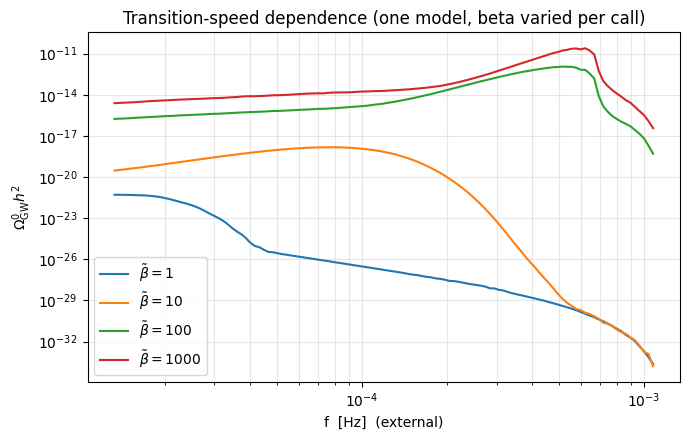

In [9]:
# a frequency grid spanning the valid band (k_out in (0, 2 k_max))
k_out_grid = np.geomspace(10., 1.8 * K_MAX, 120)
f = m.k_out_tilde_to_freq(k_out_grid)

print(f)

A_s, n_s = 2.1e-9, 0.97
plt.figure(figsize=(7, 4.5))
for b in [1.0, 10.0, 100.0, 1000.0]:
    plt.loglog(f, m(f, b, A_s, n_s), label=fr"$\tilde\beta={b:g}$")
plt.xlabel("f  [Hz]  (external)"); plt.ylabel(r"$\Omega_{\rm GW}^0 h^2$")
plt.title("Transition-speed dependence (one model, beta varied per call)")
plt.legend(); plt.grid(True, which="both", alpha=0.3); plt.tight_layout(); plt.show()

## 3. Arbitrary Python $P_\zeta$

`P_zeta` is just a callable; its parameters trail the kernel params in the
call. Here a log-normal bump `pz(k, A, k_c, sigma)`, so the full call is
`model(f, beta, A, k_c, sigma)`.

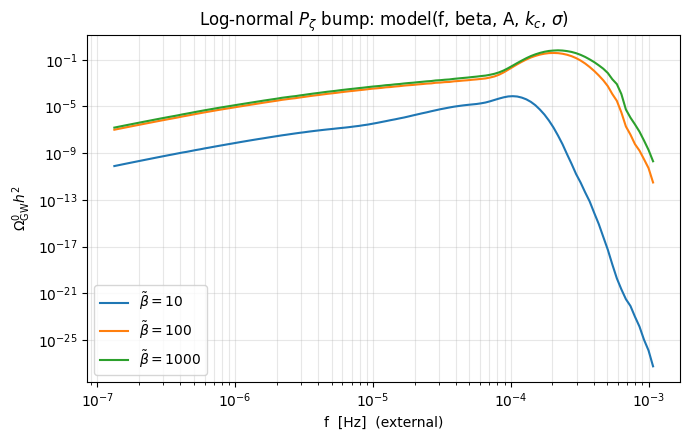

In [4]:
def pz_lognormal(k, A, k_c, sigma):
    return A * np.exp(-(np.log(k / k_c))**2 / (2 * sigma**2))

m_bump = OmegaGWPoltergeist(pz_lognormal, s=NS_NODES, t=N_T_POLE, n_t_far=N_T_FAR,
                            kappa_tol=KAPPA_TOL, T_R_GeV=T_R_GeV, k_max_tilde=K_MAX)
plt.figure(figsize=(7, 4.5))
for b in [10.0, 100.0, 1000.0]:
    plt.loglog(f, m_bump(f, b, 1e-2, 80.0, 0.4), label=fr"$\tilde\beta={b:g}$")
plt.xlabel("f  [Hz]  (external)"); plt.ylabel(r"$\Omega_{\rm GW}^0 h^2$")
plt.title(r"Log-normal $P_\zeta$ bump: model(f, beta, A, $k_c$, $\sigma$)")
plt.legend(); plt.grid(True, which="both", alpha=0.3); plt.tight_layout(); plt.show()

## 4. Convergence in the $(s, t)$ grid (the precision handle)

Resolution is a *construction* setting (`s`, `t`, `n_t_far`, `kappa_tol`) — not
an inference parameter. For a loud, well-resolved signal the likelihood is
sensitive to spectral shape, so the default grid can bias parameters. Treat the
finest as reference and look at the coarser grids' relative error.

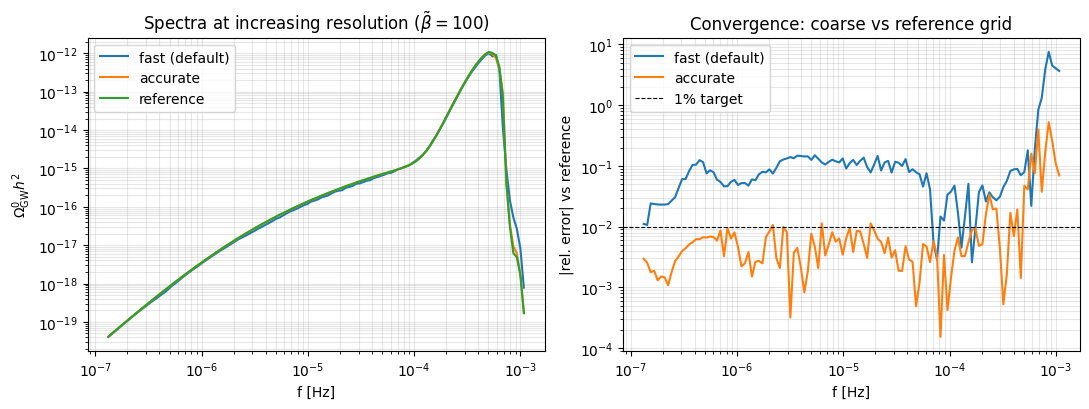

default grid worst-case relative error vs reference = 7.55
=> set resolution from a convergence study like this across your prior
   before trusting posterior widths on a loud signal.


In [5]:
# The "fast" row reuses the top-level knobs; the others tighten them. This is
# the same (s, t) resolution control as in the setup cell, swept for convergence.
presets = {
    "fast (default)": dict(s=NS_NODES, t=N_T_POLE, n_t_far=N_T_FAR, kappa_tol=KAPPA_TOL),
    "accurate":       dict(s=9,  t=80,  n_t_far=40, kappa_tol=2e-3),
    "reference":      dict(s=13, t=160, n_t_far=80, kappa_tol=5e-4),
}
b, A_s, n_s = 100.0, 2.1e-9, 0.97
spectra = {}
for name, kw in presets.items():
    mm = OmegaGWPoltergeist(power_law, T_R_GeV=T_R_GeV, k_max_tilde=K_MAX, **kw)
    spectra[name] = mm(f, b, A_s, n_s)

ref_spec = spectra["reference"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
for name in presets:
    ax1.loglog(f, spectra[name], label=name)
ax1.set_xlabel("f [Hz]"); ax1.set_ylabel(r"$\Omega_{\rm GW}^0 h^2$")
ax1.set_title(fr"Spectra at increasing resolution ($\tilde\beta={b:g}$)")
ax1.legend(); ax1.grid(True, which="both", alpha=0.3)
for name in ["fast (default)", "accurate"]:
    ax2.loglog(f, np.abs(spectra[name] - ref_spec) / np.maximum(np.abs(ref_spec), 1e-300), label=name)
ax2.axhline(1e-2, ls="--", c="k", lw=0.8, label="1% target")
ax2.set_xlabel("f [Hz]"); ax2.set_ylabel("|rel. error| vs reference")
ax2.set_title("Convergence: coarse vs reference grid")
ax2.legend(); ax2.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

worst = np.max(np.abs(spectra["fast (default)"] - ref_spec) / np.maximum(np.abs(ref_spec), 1e-300))
print(f"default grid worst-case relative error vs reference = {worst:.2f}")
print("=> set resolution from a convergence study like this across your prior")
print("   before trusting posterior widths on a loud signal.")

## 5. Hooking into GPry (sketch)

Gradient-free, so the non-differentiable C++ call is fine; each eval is
~1–3 s and OpenMP-parallel. Build the model once (fixing precision), vary the
inference vector per call.

```python
import numpy as np
from sigway.omega_gw_poltergeist import OmegaGWPoltergeist

f_data, omega_data, sigma = ...   # your LISA mock-data band [Hz]

K_PIVOT_TILDE = ...               # from pc.k_to_tilde(0.05, pc.T_R_to_eta_R(T_R))
def power_law(k, A_s, n_s):
    return A_s * (k / K_PIVOT_TILDE) ** (n_s - 1.0)

# fix precision from your convergence study
model = OmegaGWPoltergeist(power_law, s=9, t=80, n_t_far=40, kappa_tol=2e-3,
                           T_R_GeV=100.0, k_max_tilde=450.0)

def log_like(beta_tilde, log10_As, n_s):                  # order = kernel + pz
    mu = model(f_data, beta_tilde, 10**log10_As, n_s)
    return -0.5 * np.sum(((mu - omega_data) / sigma) ** 2)

# from gpry import Runner
# Runner(log_like, bounds={"beta_tilde":[1,3000],
#                          "log10_As":[-9,-8], "n_s":[0.9,1.0]}).run()
```

To infer $T_R$ too, build with `kernel_param_names=("beta_tilde","T_R_GeV")`
and call `model(f, beta_tilde, T_R_GeV, A_s, n_s)`.